In [1]:
using FFTW
using GLMakie
using Statistics
using LinearAlgebra
using DSP

In [2]:
raw = readlines("lpf_sim.csv")

52-element Vector{String}:
 "Frequency,DB(MAG(V(un4))),PHDEG(V(un4)),"
 "1000,-6.020599913279778,-0.009262800002947843,"
 "1258.9254117941673,-6.0205999132798675,-0.011661174310248736,"
 "1584.8931924611136,-6.020599913280011,-0.014680548674864381,"
 "1995.2623149688795,-6.02059991328024,-0.01848171579450931,"
 "2511.8864315095802,-6.020599913280598,-0.02326710168450714,"
 "3162.2776601683795,-6.020599913281167,-0.029291545603826716,"
 "3981.0717055349724,-6.020599913282069,-0.03687587118002581,"
 "5011.872336272723,-6.020599913283501,-0.04642397144753873,"
 "6309.573444801932,-6.020599913285768,-0.058444317644976644,"
 "7943.282347242815,-6.0205999132893595,-0.0735770372034633,"
 "10000,-6.0205999132950545,-0.09262800294784566,"
 "12589.254117941671,-6.020599913304079,-0.11661174892539586,"
 ⋮
 "7943282.347242815,-6.020957239870835,-75.1879162636899,"
 "10000000,-6.024676527336365,-96.04502484196797,"
 "12589254.117941672,-6.062720589971703,-124.22260865200019,"
 "15848931.924611134,-

In [3]:
data = map(d -> parse.(Float64,split(d,",")[1:3]),raw[2:end])
Fs = map(d -> d[1],data)
mag = map(d -> d[2],data)
mag = mag.-mag[1]
phase = map(d -> d[3],data)/180*pi

51-element Vector{Float64}:
 -0.00016166635800518033
 -0.0002035258863628192
 -0.00025622391037567396
 -0.00032256679203202714
 -0.0004060875317909685
 -0.0005112339137848468
 -0.000643605366632737
 -0.0008102511536113888
 -0.001020045771986261
 -0.0012841615530627957
 -0.0016166636309869202
 -0.002035258965257117
 -0.0025622393065331296
  ⋮
 -1.3122766965151818
 -1.6763019136520876
 -2.168093526393798
 -2.877413952953746
 -3.9113957738411687
 -4.950895067429576
 -5.6665983142336405
 -6.162639779482388
 -6.529794690316337
 -6.810854044936558
 -7.029511616819155
 -7.201074818599078

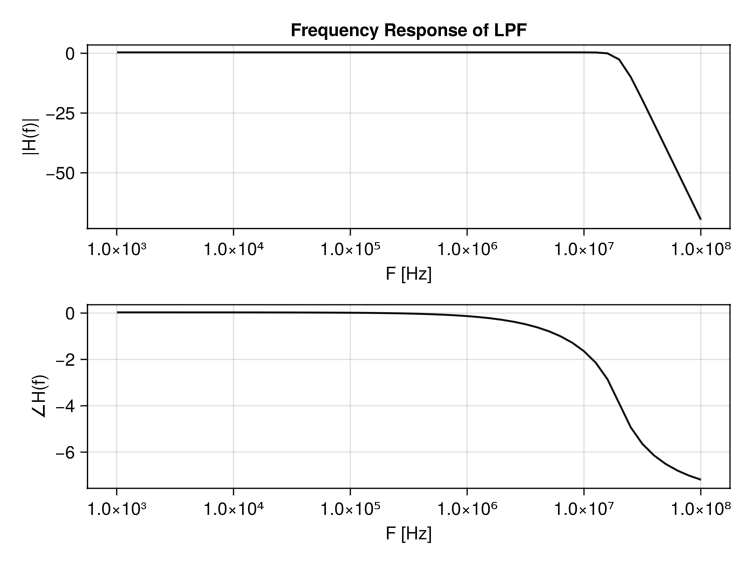

In [4]:
fig = Figure()
ax = Axis(fig[1,1],xlabel="F [Hz]",ylabel="|H(f)|",title="Frequency Response of LPF",xscale=log10,xticks=[1,10,10e1,10e2,10e3,10e4,10e5,10e6,10e7,10e8])
lines!(ax,Fs,mag,color=:black)
ax = Axis(fig[2,1],xlabel="F [Hz]",ylabel="∠H(f)",xscale=log10,xticks=[1,10,10e1,10e2,10e3,10e4,10e5,10e6,10e7,10e8])
lines!(ax,Fs,phase,color=:black)
fig